## Machine Learning - Prevenção de Fraudes

<p> Conjunto de dados com mais de 80.000 registros<br>
Analise exploratória de variáveis categórias e numéricas<br>
Analise e tratamento de valores missing (nulos)<br>
Analise estatística de variáveis<br>
Tratamento de Dados<br>     
Engenharia de Atributos<br>    
Gráficos<br>
Outliers<br>
Normalização e Padronização de Dados<br>
Balanceamento da variável ALVO (TARGET)<br>    
OneHotEncoding<br>
Criação, treino e teste dos modelos preditivos com 3 algoritmos diferentes (Random Forest, Suport Vector Machine e KNN<br>
GridSearch para ajustes de hiperparametros automáticos e treino de mais de 1.000 modelos    
Analise dos pesos das melhores variáveis 

### Importante Pacotes e Carregando o Dataset

In [1]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore") 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.2f}'.format


In [2]:
import sys
print(sys.executable)

import sklearn, imblearn
print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("Ambiente OK 🎉")

c:\Users\Kiko\AppData\Local\Programs\Python\Python312\python.exe
sklearn: 1.8.0
imblearn: 0.14.1
Ambiente OK 🎉


In [3]:
#Importação do arquivo de dados

#df_original=pd.read_csv("dados_coletados_20k.csv")
#df_original=pd.read_csv("dados_coletados_80k.csv")

df_original = pd.read_csv("dados_coletados10k.csv")

## Analise Exploratória - Visão Geral
Aqui o objetivo desta analise é ter uma visão geral do conjunto de dados, compreendendo seu tamanho, variaveis, 
tipo de dados e período dos dados coletados.

In [4]:
#Tamanho do conjunto, linhas e colunas
df_original.shape

df_original.head()

,Contrato,Idade,Sexo,Valor_Renda,UF_Cliente,Perc_Juros,Prazo_Emprestimo,Data_Contratacao,Prazo_Restante,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,Estado_Civil,Escolaridade,Possui_Patrimonio,VL_Patrimonio,QT_Parcelas_Atraso,QT_Dias_Atraso,Saldo_Devedor,Total_Pago,Possivel_Fraude
0,322068935715,43,M,5800.00,SP,23.00,200,2022-08-01,193,80000.00,92000.00,15,9,1,0,DIVORCIADO,Nenhum,N,0.00,0,NaN,91759.97,7717.08,Nao
1,322068936715,22,M,2000.00,MG,20.00,100,2022-08-01,89,50000.00,57500.00,10,10,0,0,SOLTEIRO(A),NaN,N,0.00,4,103.00,53981.18,6756.59,Nao
2,322068938715,35,M,4000.00,BA,18.00,100,2022-08-01,85,100000.00,115000.00,15,5,1,0,CASADO (A),NaN,N,0.00,0,NaN,101150.02,17929.06,Nao
3,322068939715,20,M,1800.00,MG,20.00,100,2022-08-01,89,30000.00,34500.00,1,1,0,0,SOLTEIRO(A),NaN,N,0.00,13,376.00,36208.10,369.10,Sim
4,322068940715,53,M,2800.00,MG,20.00,100,2022-08-01,87,60000.00,69000.00,16,16,0,0,CASADO (A),NaN,N,0.00,0,NaN,60984.00,11845.24,Nao


In [5]:
#periodo dos dados coletado
inicio = pd.to_datetime(df_original["Data_Contratacao"]).dt.date.min()
fim = pd.to_datetime(df_original["Data_Contratacao"]).dt.date.max()
print(f"Período dos dados - De:{inicio} Até: {fim}")

Período dos dados - De:2022-07-04 Até: 2022-12-20


In [6]:
#virificação de dados nulos
df_original.isnull().sum()

Contrato                               0
Idade                                  0
Sexo                                   0
Valor_Renda                            0
UF_Cliente                             0
Perc_Juros                             0
Prazo_Emprestimo                       0
Data_Contratacao                       0
Prazo_Restante                         0
VL_Emprestimo                          0
VL_Emprestimo_ComJuros                 0
QT_Total_Parcelas_Pagas                0
QT_Total_Parcelas_Pagas_EmDia          0
QT_Total_Parcelas_Pagas_EmAtraso       0
Qt_Renegociacao                        0
Estado_Civil                           0
Escolaridade                        7105
Possui_Patrimonio                      0
VL_Patrimonio                          0
QT_Parcelas_Atraso                     0
QT_Dias_Atraso                      3594
Saldo_Devedor                          0
Total_Pago                             0
Possivel_Fraude                        0
dtype: int64

In [7]:
#Informções basicas sobre o DF
df_original.info(verbose=True) #verbose -> mostra os dados um uma celula só sem barra de rolagem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Contrato                          9517 non-null   int64  
 1   Idade                             9517 non-null   int64  
 2   Sexo                              9517 non-null   object 
 3   Valor_Renda                       9517 non-null   float64
 4   UF_Cliente                        9517 non-null   object 
 5   Perc_Juros                        9517 non-null   float64
 6   Prazo_Emprestimo                  9517 non-null   int64  
 7   Data_Contratacao                  9517 non-null   object 
 8   Prazo_Restante                    9517 non-null   int64  
 9   VL_Emprestimo                     9517 non-null   float64
 10  VL_Emprestimo_ComJuros            9517 non-null   float64
 11  QT_Total_Parcelas_Pagas           9517 non-null   int64  
 12  QT_Tot

In [8]:
#total de valores unicos para cada variavel
valores_unicos = []

for i in df_original.columns[0:24].tolist():
    print(i, ':', len(df_original[i].astype(str).value_counts()))
    valores_unicos.append(df_original[i].astype(str).value_counts())

Contrato : 9517
Idade : 74
Sexo : 2
Valor_Renda : 855
UF_Cliente : 27
Perc_Juros : 21
Prazo_Emprestimo : 36
Data_Contratacao : 110
Prazo_Restante : 79
VL_Emprestimo : 61
VL_Emprestimo_ComJuros : 61
QT_Total_Parcelas_Pagas : 24
QT_Total_Parcelas_Pagas_EmDia : 24
QT_Total_Parcelas_Pagas_EmAtraso : 15
Qt_Renegociacao : 10
Estado_Civil : 6
Escolaridade : 6
Possui_Patrimonio : 2
VL_Patrimonio : 3
QT_Parcelas_Atraso : 16
QT_Dias_Atraso : 16
Saldo_Devedor : 7654
Total_Pago : 7022
Possivel_Fraude : 2


In [9]:
#Medidas estatisticas
df_original.describe()

,Contrato,Idade,Valor_Renda,Perc_Juros,Prazo_Emprestimo,Prazo_Restante,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,VL_Patrimonio,QT_Parcelas_Atraso,QT_Dias_Atraso,Saldo_Devedor,Total_Pago
count,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,5923.00,9517.00,9517.00
mean,322078158460.93,38.74,8325.40,19.65,107.43,104.58,81881.89,94164.17,7.89,4.11,1.60,1.24,10.93,5.35,249.79,90560.27,8166.21
std,5434160.86,12.67,121862.06,3.82,62.49,68.57,94138.06,108258.77,5.17,4.04,2.31,1.17,1025.26,5.32,123.22,111050.54,16697.76
min,322068935715.00,6.00,450.00,7.00,15.00,0.00,3500.00,4025.00,0.00,0.00,0.00,0.00,0.00,0.00,11.00,0.00,0.00
25%,322073331715.00,29.00,2300.00,18.00,60.00,51.00,20000.00,23000.00,2.00,1.00,0.00,0.00,0.00,0.00,162.00,18546.85,1202.04
50%,322078461715.00,37.00,3400.00,20.00,80.00,80.00,50000.00,57500.00,9.00,2.00,1.00,1.00,0.00,4.00,284.00,45375.30,3949.91
75%,322082622715.00,46.00,5000.00,22.00,190.00,185.00,100000.00,115000.00,13.00,6.00,2.00,2.00,0.00,11.00,344.00,119721.25,8302.01
max,322087622715.00,91.00,8000080.00,28.00,240.00,227.00,500000.00,575000.00,35.00,35.00,14.00,9.00,100000.00,15.00,435.00,625000.00,396385.00


In [10]:
#analisando maior e menor Valor_Renda
print(f"Maior Renda: {df_original['Valor_Renda'].max()}")
print(f"Menor Renda: {df_original['Valor_Renda'].min()}")

Maior Renda: 8000080.0
Menor Renda: 450.0


In [11]:
#analisando maior e menor QT_Dias_Atraso
print(f"Mais dias de atraso: {df_original['QT_Dias_Atraso'].max()}")
print(f"Menos dias de atraso: {df_original['QT_Dias_Atraso'].min()}")

Mais dias de atraso: 435.0
Menos dias de atraso: 11.0


In [12]:
#analisando maior e menor Prazo_Restante
print(f"Maior Prazo: {df_original['Prazo_Restante'].max()}")
print(f"Menor Prazo: {df_original['Prazo_Restante'].min()}")

Maior Prazo: 227
Menor Prazo: 0


In [13]:
#Agrupamento de dias em atraso
df_original.groupby(['QT_Dias_Atraso']).size()

QT_Dias_Atraso
11.00     532
41.00     255
71.00     190
103.00    205
133.00    176
162.00    206
194.00    241
225.00    352
251.00    471
284.00    546
315.00    718
344.00    930
376.00    686
406.00    413
435.00      2
dtype: int64

In [14]:
#Agrupamento Prazo_Emprestimo
df_original.groupby(['Prazo_Emprestimo']).size()

Prazo_Emprestimo
15        4
18        4
19        5
20      146
25      183
30      272
34        1
35       81
36      306
40      136
42       20
45      205
48      333
50      184
55      185
60      890
65       36
70      134
75      455
80     1421
88        2
90      354
95      135
100     928
120     102
130      21
140     167
150      48
160      33
165       3
170      78
180     129
190     674
200    1661
235      71
240     110
dtype: int64

In [15]:
#Agrupamento Prazo_Restante
df_original.groupby(['Prazo_Restante']).size()

Prazo_Restante
0        2
3        3
4        2
6       22
7       29
8       31
9        8
10      12
11      32
12       6
13      94
15      10
16      42
17      85
18      27
19     143
20      23
23     164
25      84
27      38
28      52
29      71
30      51
31      71
33      40
34      67
35     168
36     204
37      31
38      55
39      22
40      73
41      37
42      14
43      27
44     126
45      19
46       2
49     145
50      19
51     256
53     150
59       7
60     178
64     421
66      43
68     330
71     270
74     304
75     193
76      99
77      67
78      63
79      86
80     188
82     159
84      48
85      72
87     129
89     420
91     705
100     15
107     43
120     24
125     68
129     44
133     25
143    197
149     16
156     39
159     58
175    119
179     27
185    332
193    764
198    337
221     17
225    534
227    519
dtype: int64

In [16]:
#Agrupamento Sexo
df_original.groupby(['Sexo']).size()

Sexo
F    3811
M    5706
dtype: int64

In [17]:
#Agrupamento UF_Cliente
df_original.groupby(['UF_Cliente']).size()

UF_Cliente
AC       1
AL      79
AM       2
AP       5
BA     883
CE     248
DF      46
ES      49
GO     485
MA     403
MG    1637
MS     238
MT     137
PA     420
PB     154
PE     263
PI     104
PR     693
RJ     335
RN      78
RO      16
RR       4
RS     407
SC     298
SE      45
SP    2468
TO      19
dtype: int64

In [18]:
#Agrupamento Idade
df_original.groupby(['Idade']).size()

Idade
6       1
17      4
18      6
19    109
20    207
21    193
22    173
23    234
24    251
25    253
26    296
27    277
28    280
29    298
30    284
31    281
32    288
33    273
34    310
35    336
36    280
37    262
38    271
39    270
40    264
41    270
42    243
43    233
44    285
45    229
46    208
47    177
48    167
49    172
50    148
51    143
52    118
53    122
54    124
55    124
56     96
57     76
58     90
59     79
60     99
61     71
62     56
63     49
64     54
65     37
66     65
67     39
68     48
69     33
70     27
71     16
72     19
73     16
74     16
75      7
76     12
77      5
78      5
79      3
80      9
81      5
82      3
83      4
84      2
85      5
87      2
88      2
90      2
91      1
dtype: int64

In [19]:
#Agrupamento Estado_Civil
df_original.groupby(['Estado_Civil']).size()

Estado_Civil
CASADO (A)       3027
DIVORCIADO        481
OUTRO             652
SOLTEIRO(A)      5087
UNIÃO ESTAVEL     130
VIÚVO(A)          140
dtype: int64

In [20]:
#Agrupamento Escolaridade
df_original.groupby(['Escolaridade']).size()

Escolaridade
Ensino Fundamental                        18
Ensino Médio                             129
Ensino Superior                           74
Nenhum                                  2184
Pós Graduação / Mestrado / Doutorado       7
dtype: int64

In [21]:
#Agrupamento Possui_Patrimonio
df_original.groupby(['Possui_Patrimonio']).size()

Possui_Patrimonio
N    9452
S      65
dtype: int64

In [22]:
#Agrupamento Valor_Patrimonio
df_original.groupby(['VL_Patrimonio']).size()

VL_Patrimonio
0.00         9512
1000.00         4
100000.00       1
dtype: int64

In [23]:
#Agrupamento Possivel_Fraude
df_original.groupby(['Possivel_Fraude']).size()

Possivel_Fraude
Nao    5035
Sim    4482
dtype: int64

### Tratamento de Dados
Tratando os dados que identificamos que precisar ser ajustados em nossa análise acima

In [24]:
#Ajuste Estado_Civil
df_original['Estado_Civil'] = df_original['Estado_Civil'].replace(['NENHUM'], 'OUTRO')
df_original['Estado_Civil'] = df_original['Estado_Civil'].replace(['UNIÃO ESTAVEL'], 'CASADO (A)')

df_original.groupby(['Estado_Civil']).size()

Estado_Civil
CASADO (A)     3157
DIVORCIADO      481
OUTRO           652
SOLTEIRO(A)    5087
VIÚVO(A)        140
dtype: int64

In [25]:
#Criação da coluna de faixa etaria
idades = [0, 21, 30, 40, 50, 60, 100]
faixas = ['Até 21 anos', 'de 22 a 30 anos', 'de 31 a 40 anos', 'de 41 a 50 anos', 'de 51 a 60 anos', 'Acima de 60 anos']
df_original['Faixa_Etaria'] = pd.cut(df_original['Idade'], bins=idades, labels=faixas)

df_original.groupby(['Faixa_Etaria']).size()

Faixa_Etaria
Até 21 anos          520
de 22 a 30 anos     2346
de 31 a 40 anos     2835
de 41 a 50 anos     2132
de 51 a 60 anos     1071
Acima de 60 anos     613
dtype: int64

In [26]:
df_original.head()

,Contrato,Idade,Sexo,Valor_Renda,UF_Cliente,Perc_Juros,Prazo_Emprestimo,Data_Contratacao,Prazo_Restante,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,Estado_Civil,Escolaridade,Possui_Patrimonio,VL_Patrimonio,QT_Parcelas_Atraso,QT_Dias_Atraso,Saldo_Devedor,Total_Pago,Possivel_Fraude,Faixa_Etaria
0,322068935715,43,M,5800.00,SP,23.00,200,2022-08-01,193,80000.00,92000.00,15,9,1,0,DIVORCIADO,Nenhum,N,0.00,0,NaN,91759.97,7717.08,Nao,de 41 a 50 anos
1,322068936715,22,M,2000.00,MG,20.00,100,2022-08-01,89,50000.00,57500.00,10,10,0,0,SOLTEIRO(A),NaN,N,0.00,4,103.00,53981.18,6756.59,Nao,de 22 a 30 anos
2,322068938715,35,M,4000.00,BA,18.00,100,2022-08-01,85,100000.00,115000.00,15,5,1,0,CASADO (A),NaN,N,0.00,0,NaN,101150.02,17929.06,Nao,de 31 a 40 anos
3,322068939715,20,M,1800.00,MG,20.00,100,2022-08-01,89,30000.00,34500.00,1,1,0,0,SOLTEIRO(A),NaN,N,0.00,13,376.00,36208.10,369.10,Sim,Até 21 anos
4,322068940715,53,M,2800.00,MG,20.00,100,2022-08-01,87,60000.00,69000.00,16,16,0,0,CASADO (A),NaN,N,0.00,0,NaN,60984.00,11845.24,Nao,de 51 a 60 anos


In [27]:
#Criação da coluna de faixa salarial
salarios = [-100, 1000, 2000, 3000, 5000, 10000, 20000, 30000, 90000000]
faixas = ['Até 1k', 'de 1k até 2k', 'de 2k até 3k', 'de 3k até 5k', 'de 5k até 10k', 'de 10k até 20k', 'de 20k até 30k',  'Acima de 50k']
df_original['Faixa_Salarial'] = pd.cut(df_original['Valor_Renda'], bins=salarios, labels=faixas)

df_original.groupby(['Faixa_Salarial']).size()

Faixa_Salarial
Até 1k              19
de 1k até 2k      2012
de 2k até 3k      2522
de 3k até 5k      2646
de 5k até 10k     1574
de 10k até 20k     488
de 20k até 30k     137
Acima de 50k       119
dtype: int64

In [28]:
#precisamos preencjer os valores nulos da variavel QT_Dias_Atraso
#vamos preencher usando a mediana dos dados
df_original['QT_Dias_Atraso'].median()

#preenchendo os valores nulos
df_original['QT_Dias_Atraso'] = df_original['QT_Dias_Atraso'].fillna((df_original['QT_Dias_Atraso'].median()))

In [29]:
#Criação da faixa de dias em atraso
dias = [-100, 30, 60, 90, 180, 240, 360, 500]
faixas = ['Até 30 Dias', 'de 31 até 60', 'de 61 até 90', 'de 91 até 180', 'de 181 até 240', 'de 241 até 360', 'Acima de 360']
df_original['Faixa_Dias_Atraso'] = pd.cut(df_original['QT_Dias_Atraso'], bins=dias, labels=faixas)

df_original.groupby(['Faixa_Dias_Atraso']).size()

Faixa_Dias_Atraso
Até 30 Dias        532
de 31 até 60       255
de 61 até 90       190
de 91 até 180      587
de 181 até 240     593
de 241 até 360    6259
Acima de 360      1101
dtype: int64

In [30]:
# Criando faixa de prazo de emprestimo para utilizarmos no modelo preditivo
bins = [0, 60, 120, 200, 720]
labels = ['Até 60 Meses', 'De 61 até 120 Meses', 'De 121 até 200 Meses', 'Acima de 200 Meses']
df_original['Faixa_Prazo_Emprestimo'] = pd.cut(df_original['Prazo_Emprestimo'], bins=bins, labels=labels)
pd.value_counts(df_original.Faixa_Prazo_Emprestimo)

Faixa_Prazo_Emprestimo
De 61 até 120 Meses     3567
Até 60 Meses            2955
De 121 até 200 Meses    2814
Acima de 200 Meses       181
Name: count, dtype: int64

In [31]:
# Criando faixa de prazo restante do emprestimo para utilizarmos no modelo preditivo
bins = [-1, 60, 120, 200, 500]
labels = ['Até 60 Meses', 'De 61 até 120 Meses', 'De 121 até 200 Meses', 'Acima de 200 Meses']
df_original['Faixa_Prazo_Restante'] = pd.cut(df_original['Prazo_Restante'], bins=bins, labels=labels)
pd.value_counts(df_original.Faixa_Prazo_Restante)

Faixa_Prazo_Restante
De 61 até 120 Meses     3679
Até 60 Meses            2742
De 121 até 200 Meses    2026
Acima de 200 Meses      1070
Name: count, dtype: int64

### Visualização dos Dados

Agora após os ajustes vamos visualizar de forma gráfica para avaliarmos melhor

<Axes: title={'center': 'Sexo'}, xlabel='Sexo'>

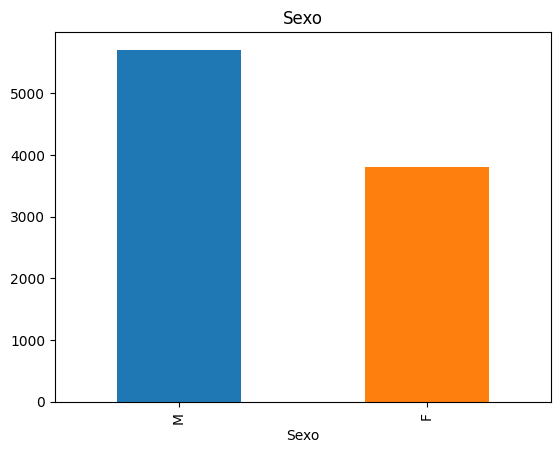

In [32]:
df_original.Sexo.value_counts().plot(kind='bar', title='Sexo', color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'UF Cliente'}, xlabel='UF_Cliente'>

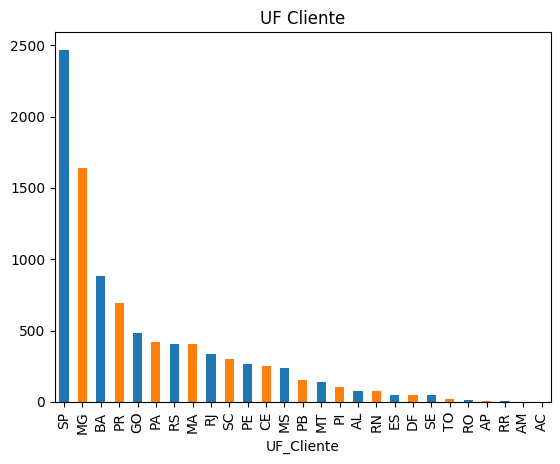

In [33]:
df_original.UF_Cliente.value_counts().plot(kind='bar', title='UF Cliente', color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Prazo Emprestimo'}, xlabel='Faixa_Prazo_Emprestimo'>

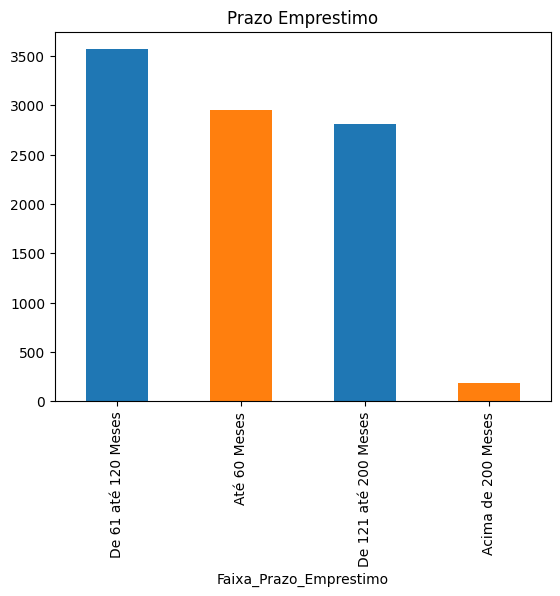

In [34]:
df_original.Faixa_Prazo_Emprestimo.value_counts().plot(kind='bar', title='Prazo Emprestimo', color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Prazo Restante'}, xlabel='Faixa_Prazo_Restante'>

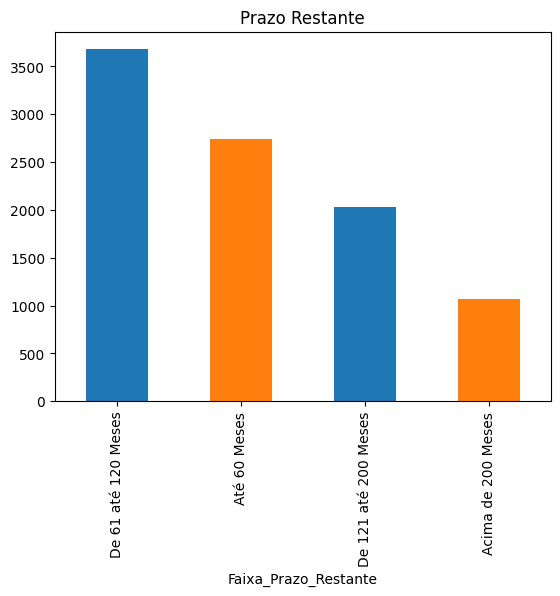

In [35]:
df_original.Faixa_Prazo_Restante.value_counts().plot(kind='bar', title='Prazo Restante', color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Estado Civil'}, xlabel='Estado_Civil'>

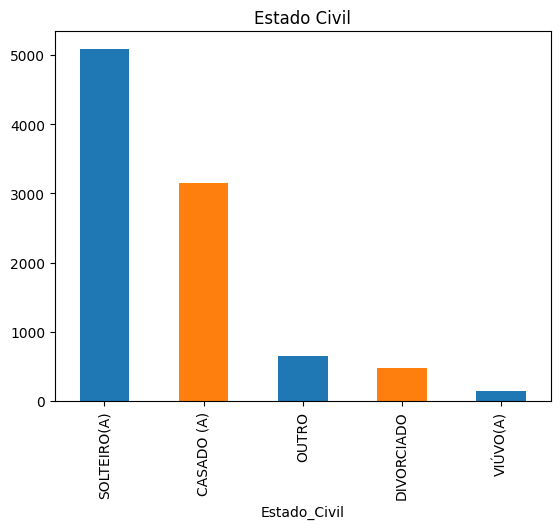

In [36]:
df_original.Estado_Civil.value_counts().plot(kind='bar', title='Estado Civil',color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Escolaridade'}, xlabel='Escolaridade'>

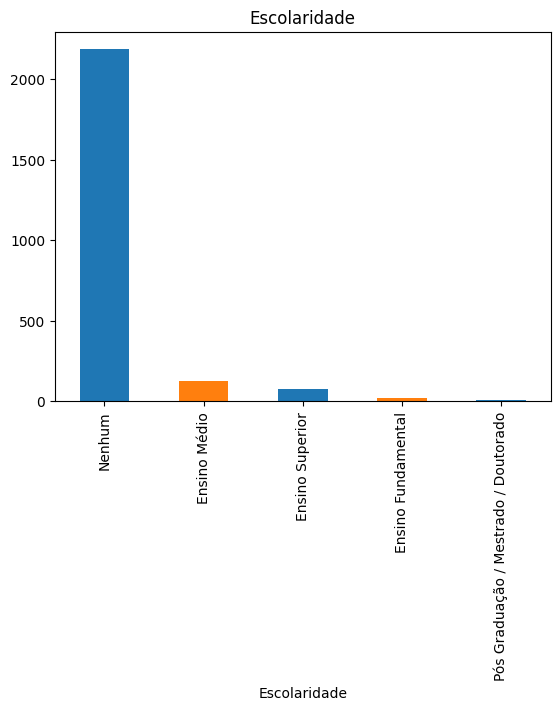

In [37]:
df_original.Escolaridade.value_counts().plot(kind='bar', title='Escolaridade',color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Faixa Dias Atraso'}, xlabel='Faixa_Dias_Atraso'>

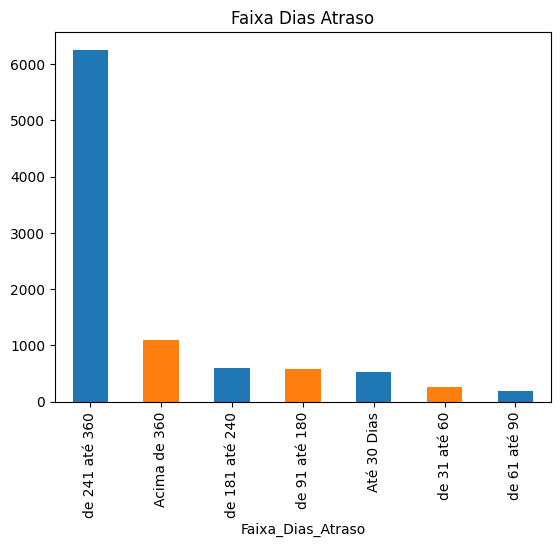

In [38]:
df_original.Faixa_Dias_Atraso.value_counts().plot(kind='bar', title='Faixa Dias Atraso',color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Faixa Salarial'}, xlabel='Faixa_Salarial'>

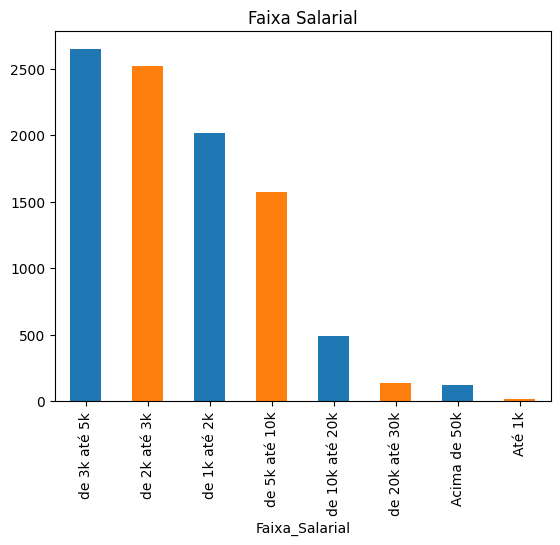

In [39]:
df_original.Faixa_Salarial.value_counts().plot(kind='bar', title='Faixa Salarial',color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Possui Patrimonio'}, xlabel='Possui_Patrimonio'>

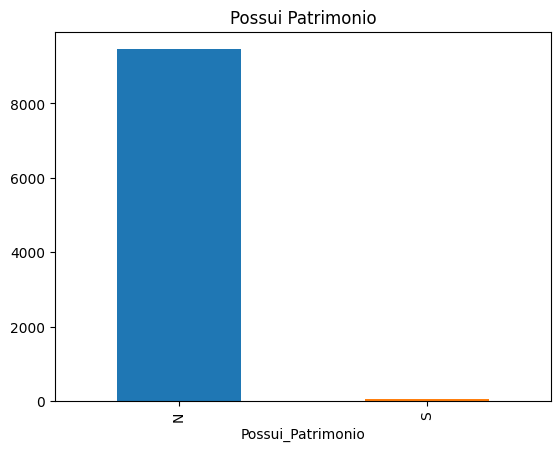

In [40]:
df_original.Possui_Patrimonio.value_counts().plot(kind='bar', title='Possui Patrimonio',color = ['#1F77B4', '#FF7F0E'])

<Axes: title={'center': 'Faixa Etaria'}, xlabel='Faixa_Etaria'>

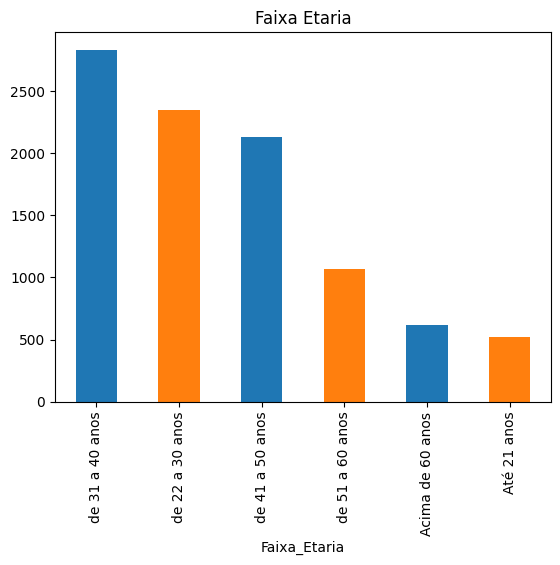

In [41]:
df_original.Faixa_Etaria.value_counts().plot(kind='bar', title='Faixa Etaria',color = ['#1F77B4', '#FF7F0E'])

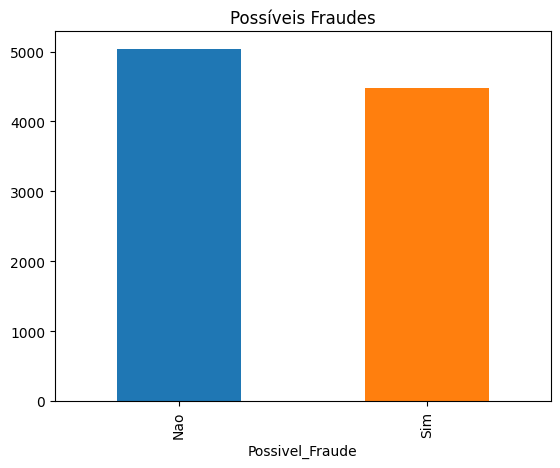

In [42]:
#Analisando como a variavel alvo está distribuida.
df_original.Possivel_Fraude.value_counts().plot(kind='bar', title='Possíveis Fraudes',color = ['#1F77B4', '#FF7F0E']);

In [43]:
# Vamos visualizar novamente como está nosso DataFrame original após a engenharia de atributos
df_original.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Contrato                          9517 non-null   int64   
 1   Idade                             9517 non-null   int64   
 2   Sexo                              9517 non-null   object  
 3   Valor_Renda                       9517 non-null   float64 
 4   UF_Cliente                        9517 non-null   object  
 5   Perc_Juros                        9517 non-null   float64 
 6   Prazo_Emprestimo                  9517 non-null   int64   
 7   Data_Contratacao                  9517 non-null   object  
 8   Prazo_Restante                    9517 non-null   int64   
 9   VL_Emprestimo                     9517 non-null   float64 
 10  VL_Emprestimo_ComJuros            9517 non-null   float64 
 11  QT_Total_Parcelas_Pagas           9517 non-null   int64 

In [44]:
df_original.columns

Index(['Contrato', 'Idade', 'Sexo', 'Valor_Renda', 'UF_Cliente', 'Perc_Juros',
       'Prazo_Emprestimo', 'Data_Contratacao', 'Prazo_Restante',
       'VL_Emprestimo', 'VL_Emprestimo_ComJuros', 'QT_Total_Parcelas_Pagas',
       'QT_Total_Parcelas_Pagas_EmDia', 'QT_Total_Parcelas_Pagas_EmAtraso',
       'Qt_Renegociacao', 'Estado_Civil', 'Escolaridade', 'Possui_Patrimonio',
       'VL_Patrimonio', 'QT_Parcelas_Atraso', 'QT_Dias_Atraso',
       'Saldo_Devedor', 'Total_Pago', 'Possivel_Fraude', 'Faixa_Etaria',
       'Faixa_Salarial', 'Faixa_Dias_Atraso', 'Faixa_Prazo_Emprestimo',
       'Faixa_Prazo_Restante'],
      dtype='object')

In [45]:
# APÓS ANALISE INICIAL QUE REALIZAMOS ACIMA, ENTENDEMOSO QUE ALGUMAS VARIÁVEIS NÃO POSSUEM RELEVANCIA.

#  Contrato --> Essa variável é a identificação de cada cliente
#  Data_Contratacao, VL_Patrimonio, Possui_Patrimonio, Escolaridade, Idade --> Essas não irão ter relevancia no modelo
#  Valor_Renda, Prazo_Emprestimo, QT_Dias_Atraso, Prazo_Restante --> Essas variáveis já transformamos em categoria


# Chamaremos nosso novo conjunto de dados de df_dados

colunas = ['Sexo', 'UF_Cliente', 'Perc_Juros', 
       'VL_Emprestimo', 'VL_Emprestimo_ComJuros', 'QT_Total_Parcelas_Pagas',
       'QT_Total_Parcelas_Pagas_EmDia', 'QT_Total_Parcelas_Pagas_EmAtraso',
       'Qt_Renegociacao', 'Estado_Civil', 'QT_Parcelas_Atraso', 'Saldo_Devedor', 
       'Total_Pago', 'Faixa_Prazo_Restante', 'Faixa_Salarial', 'Faixa_Prazo_Emprestimo', 'Faixa_Etaria', 
       'Faixa_Dias_Atraso', 'Possivel_Fraude']

df_dados = pd.DataFrame(df_original, columns=colunas)

In [46]:
df_dados.shape

(9517, 19)

In [47]:
df_dados.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Sexo                              9517 non-null   object  
 1   UF_Cliente                        9517 non-null   object  
 2   Perc_Juros                        9517 non-null   float64 
 3   VL_Emprestimo                     9517 non-null   float64 
 4   VL_Emprestimo_ComJuros            9517 non-null   float64 
 5   QT_Total_Parcelas_Pagas           9517 non-null   int64   
 6   QT_Total_Parcelas_Pagas_EmDia     9517 non-null   int64   
 7   QT_Total_Parcelas_Pagas_EmAtraso  9517 non-null   int64   
 8   Qt_Renegociacao                   9517 non-null   int64   
 9   Estado_Civil                      9517 non-null   object  
 10  QT_Parcelas_Atraso                9517 non-null   int64   
 11  Saldo_Devedor                     9517 non-null   float6

In [48]:
#Constatação que não ha dados nulos
df_dados.isnull().sum()

Sexo                                0
UF_Cliente                          0
Perc_Juros                          0
VL_Emprestimo                       0
VL_Emprestimo_ComJuros              0
QT_Total_Parcelas_Pagas             0
QT_Total_Parcelas_Pagas_EmDia       0
QT_Total_Parcelas_Pagas_EmAtraso    0
Qt_Renegociacao                     0
Estado_Civil                        0
QT_Parcelas_Atraso                  0
Saldo_Devedor                       0
Total_Pago                          0
Faixa_Prazo_Restante                0
Faixa_Salarial                      0
Faixa_Prazo_Emprestimo              0
Faixa_Etaria                        0
Faixa_Dias_Atraso                   0
Possivel_Fraude                     0
dtype: int64

### Analise Exploratória em Variáveis Categóricas
1 - Conhecer como a variável alvo (POSSIVEL_FRAUDE) está relacionada com as outras variáveis.<br>
2 - Iremos avaliar as variáveis categóricas para conhecimento dos dados e descartar variáveis que não fazem sentido.

In [51]:
#ajustar tamanhos do graficos
plt.rcParams['figure.figsize'] = [10.00, 4.00]
plt.rcParams['figure.autolayout'] = True

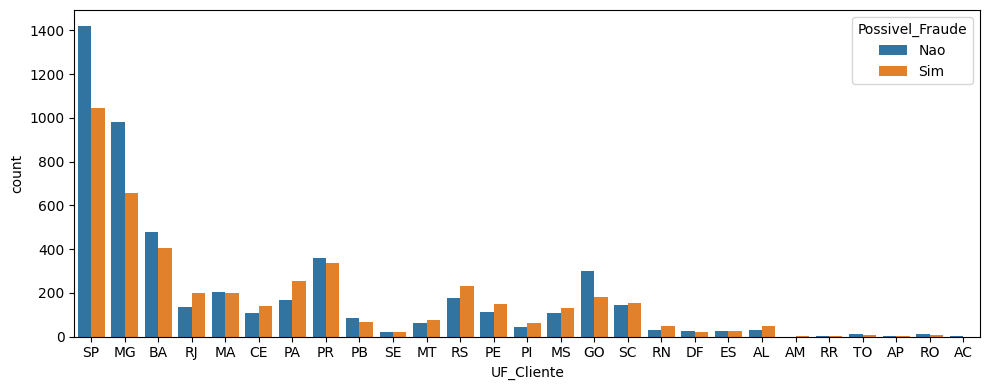

In [52]:
#Não há discrepancias nestas variaveis
sns.countplot(data=df_dados, x='UF_Cliente', hue='Possivel_Fraude')
plt.show()

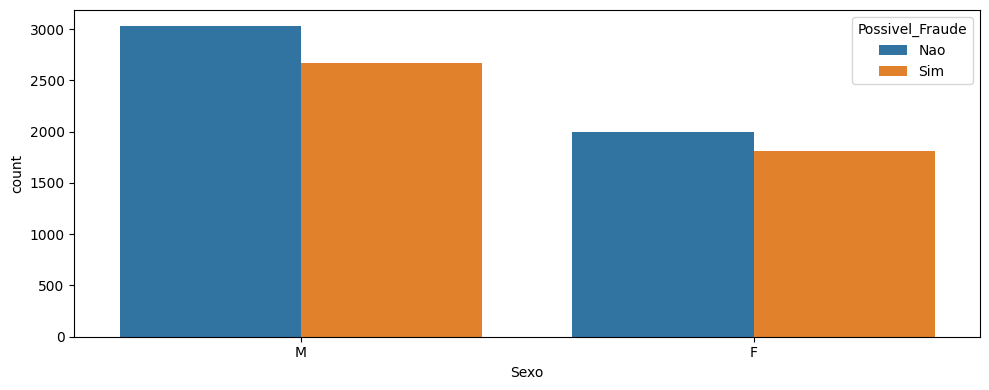

In [53]:
#Não há discrepancias nestas variaveis
sns.countplot(data=df_dados, x='Sexo', hue='Possivel_Fraude')
plt.show()

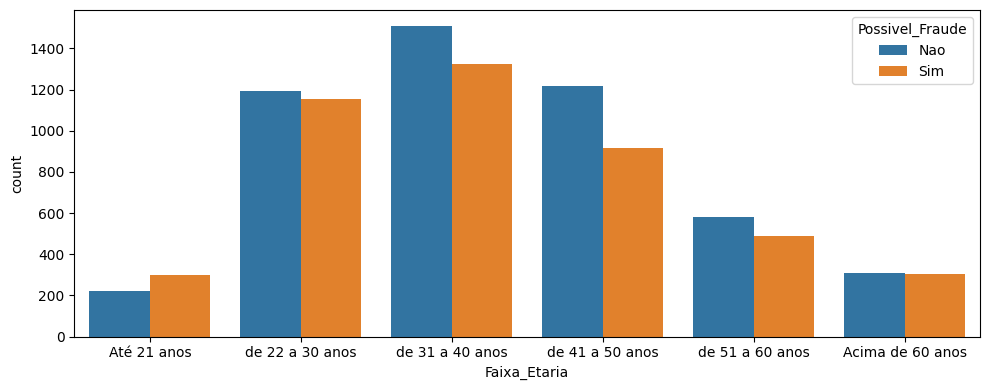

In [54]:
#Não há discrepancias nestas variaveis
sns.countplot(data=df_dados, x='Faixa_Etaria', hue='Possivel_Fraude')
plt.show()

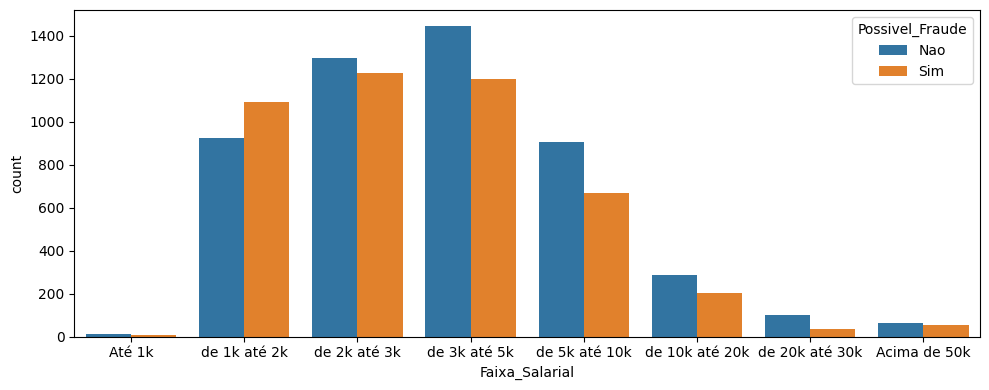

In [55]:
#Não há discrepancias nestas variaveis
sns.countplot(data=df_dados, x='Faixa_Salarial', hue='Possivel_Fraude')
plt.show()

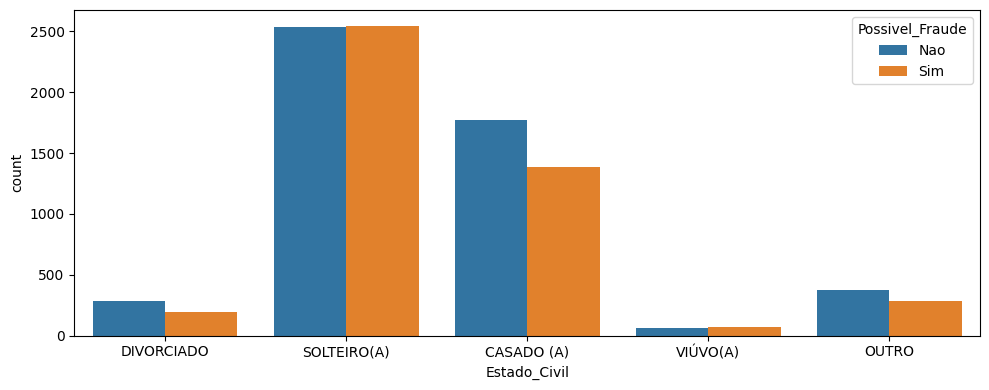

In [56]:
#Não há discrepancias nestas variaveis
sns.countplot(data=df_dados, x='Estado_Civil', hue='Possivel_Fraude')
plt.show()

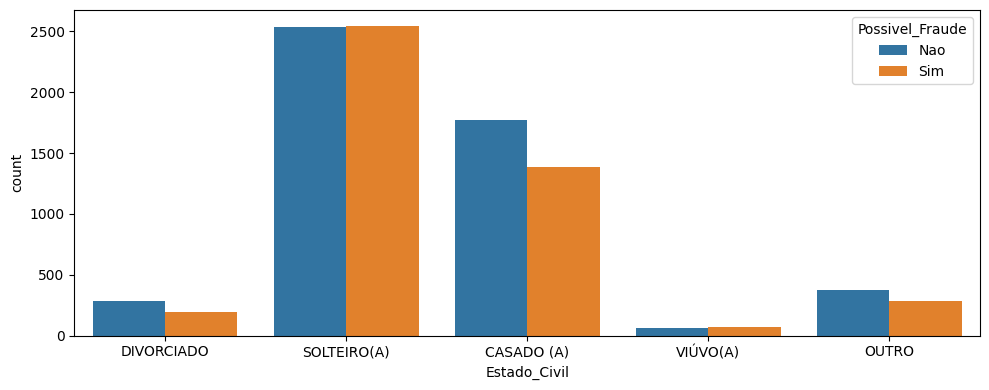

In [61]:
#Neste caso como há muitos casos de ESTADO CIVIL diferente de Casado(C) e Solteiro(S), iremos fazer um tratamento mais adiante
sns.countplot(data=df_dados, x='Estado_Civil', hue='Possivel_Fraude')
plt.show()

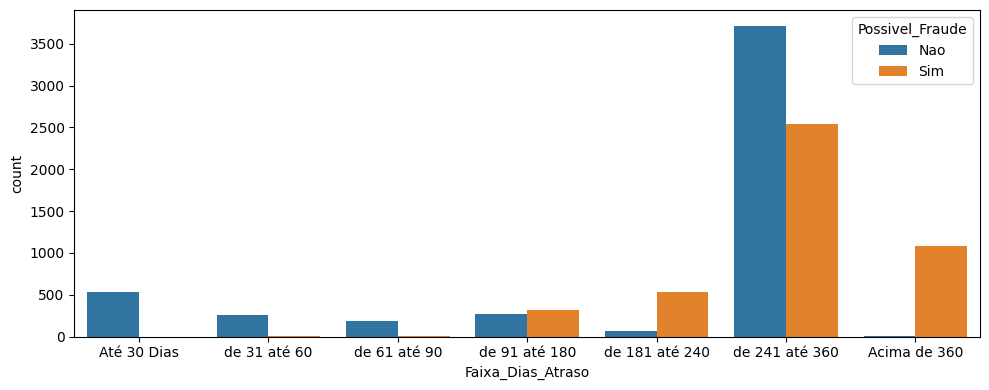

In [62]:
#Podemos observar o volume de cotas que geraram prejuízo na arrecadação de taxa de administracao
sns.countplot(data=df_dados, x='Faixa_Dias_Atraso', hue='Possivel_Fraude')
plt.show()

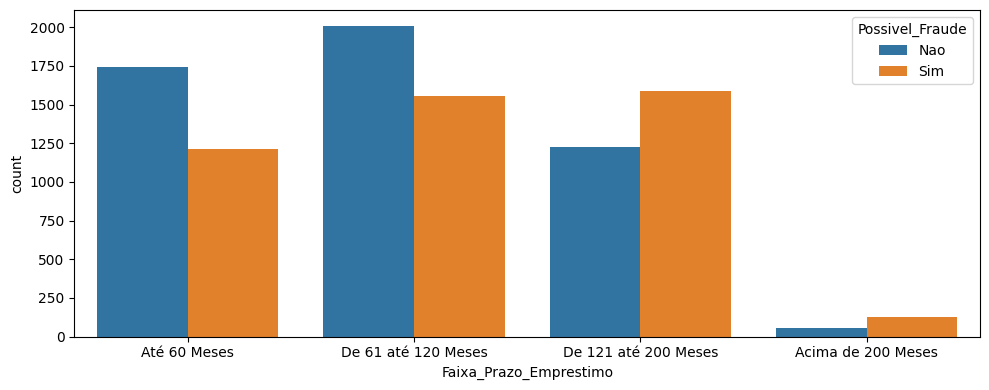

In [64]:
#Não há discrepancias nestas variaveis
sns.countplot(data=df_dados, x='Faixa_Prazo_Emprestimo', hue='Possivel_Fraude')
plt.show()

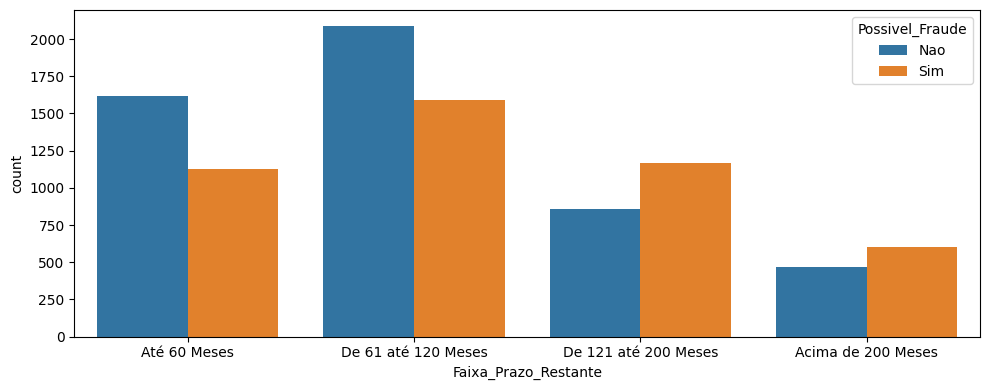

In [65]:
#Não há discrepancias nestas variaveis
sns.countplot(data=df_dados, x='Faixa_Prazo_Restante', hue='Possivel_Fraude')
plt.show()

In [66]:
df_dados.describe()

,Perc_Juros,VL_Emprestimo,VL_Emprestimo_ComJuros,QT_Total_Parcelas_Pagas,QT_Total_Parcelas_Pagas_EmDia,QT_Total_Parcelas_Pagas_EmAtraso,Qt_Renegociacao,QT_Parcelas_Atraso,Saldo_Devedor,Total_Pago
count,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00,9517.00
mean,19.65,81881.89,94164.17,7.89,4.11,1.60,1.24,5.35,90560.27,8166.21
std,3.82,94138.06,108258.77,5.17,4.04,2.31,1.17,5.32,111050.54,16697.76
min,7.00,3500.00,4025.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,18.00,20000.00,23000.00,2.00,1.00,0.00,0.00,0.00,18546.85,1202.04
50%,20.00,50000.00,57500.00,9.00,2.00,1.00,1.00,4.00,45375.30,3949.91
75%,22.00,100000.00,115000.00,13.00,6.00,2.00,2.00,11.00,119721.25,8302.01
max,28.00,500000.00,575000.00,35.00,35.00,14.00,9.00,15.00,625000.00,396385.00


In [67]:
# Total de valores únicos de cada variável do novo dataset
valores_unicos = []
for i in df_dados.columns[0:19].tolist():
    print(i, ':', len(df_dados[i].astype(str).value_counts()))
    valores_unicos.append(len(df_dados[i].astype(str).value_counts()))

Sexo : 2
UF_Cliente : 27
Perc_Juros : 21
VL_Emprestimo : 61
VL_Emprestimo_ComJuros : 61
QT_Total_Parcelas_Pagas : 24
QT_Total_Parcelas_Pagas_EmDia : 24
QT_Total_Parcelas_Pagas_EmAtraso : 15
Qt_Renegociacao : 10
Estado_Civil : 5
QT_Parcelas_Atraso : 16
Saldo_Devedor : 7654
Total_Pago : 7022
Faixa_Prazo_Restante : 4
Faixa_Salarial : 8
Faixa_Prazo_Emprestimo : 4
Faixa_Etaria : 6
Faixa_Dias_Atraso : 7
Possivel_Fraude : 2
